In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('output_data/trinuc_constraint.csv')

stats = df.groupby(['Region'])['Constraint'].agg(['mean', 'sem']).unstack()
stats.to_csv('output_data/trinuc_constraint_mean_sem.csv')
stats

      Region        
mean  cds               0.618501
      distalIG         -0.020690
      introns3UTR       0.378383
      introns5UTR       0.373675
      intronsAR         0.133234
      introns_nonUTR    0.203996
      proximal3IG       0.056705
      proximal5IG       0.050106
sem   cds               0.007667
      distalIG          0.003564
      introns3UTR       0.006571
      introns5UTR       0.008230
      intronsAR         0.008978
      introns_nonUTR    0.007612
      proximal3IG       0.010534
      proximal5IG       0.009144
dtype: float64

In [7]:
df = pd.read_csv('output_data/singlent_constraint.csv')

stats = df.groupby(['Region'])['Constraint'].agg(['mean', 'sem']).unstack()
stats.to_csv('output_data/singlent_constraint_mean_sem.csv')
stats

      Region        
mean  cds               0.550726
      distalIG         -0.013422
      introns3UTR       0.189090
      introns5UTR       0.203342
      intronsAR         0.135288
      introns_nonUTR    0.197764
      proximal3IG       0.043068
      proximal5IG       0.041064
sem   cds               0.008624
      distalIG          0.001814
      introns3UTR       0.007248
      introns5UTR       0.008843
      intronsAR         0.006319
      introns_nonUTR    0.007712
      proximal3IG       0.006392
      proximal5IG       0.006784
dtype: float64

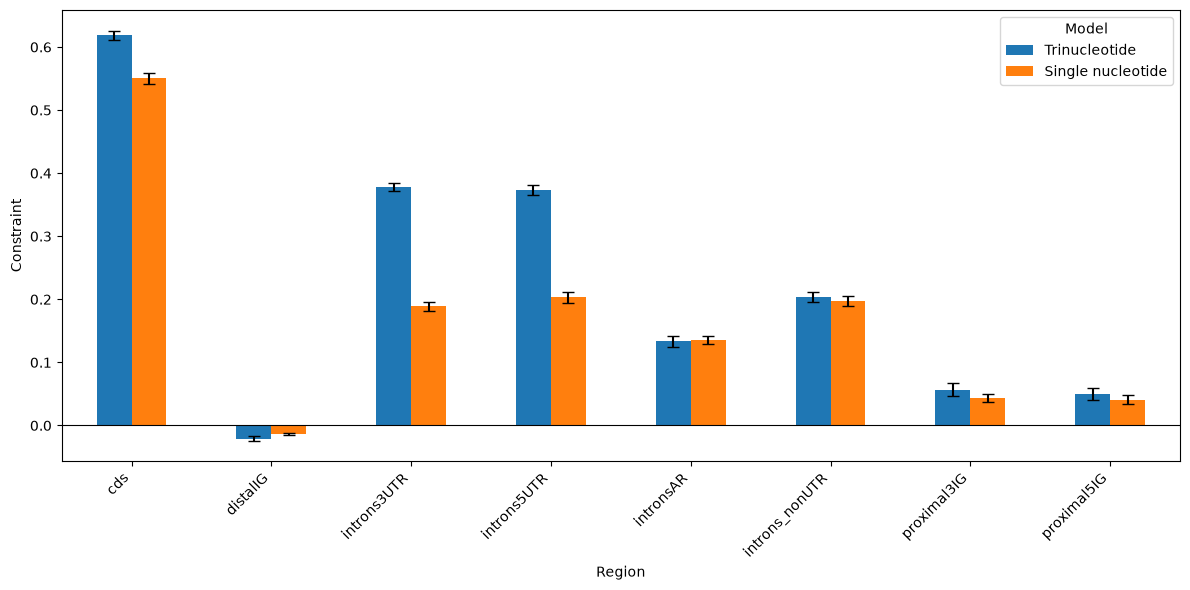

In [8]:
def region_mean_sem(path):
    df = pd.read_csv(path)
    return df.groupby('Region')['Constraint'].agg(['mean', 'sem'])

trinuc = region_mean_sem('output_data/trinuc_constraint.csv')
singlent = region_mean_sem('output_data/singlent_constraint.csv')

mean_df = pd.DataFrame({'Trinucleotide': trinuc['mean'], 'Single nucleotide': singlent['mean']})
err_df = pd.DataFrame({'Trinucleotide': trinuc['sem'], 'Single nucleotide': singlent['sem']})

ax = mean_df.plot(
    kind='bar',
    yerr=err_df,
    capsize=4,
    color=['#1f77b4', '#ff7f0e'],
    figsize=(12, 6)
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Constraint')
ax.set_xlabel('Region')
ax.legend(title='Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()